In [4]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
    

import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
sys.path.append(str(Path.cwd().parent))
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
import pandas as pd
plt.rcParams['figure.dpi'] = 100 #
import seaborn as sns
sns.set_context("poster")

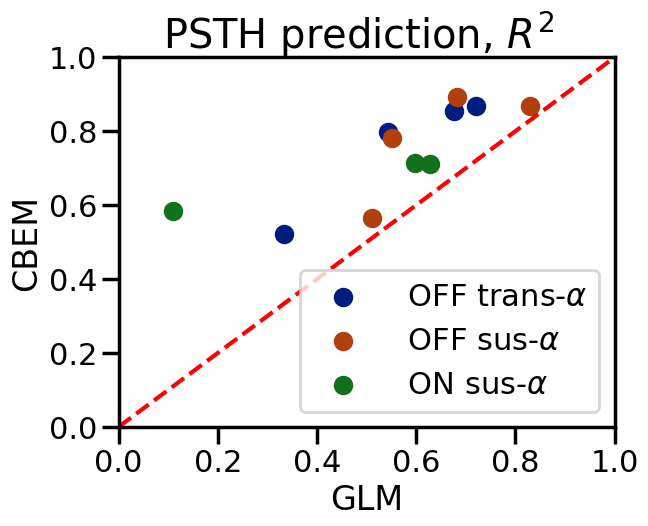

In [7]:
from matplotlib.ticker import FormatStrFormatter
sns.set_palette("dark")
OFF_tr = pd.read_csv("multi_cell/off_transient_alpha/summary.csv")
OFF_sus = pd.read_csv("multi_cell/off_sustained_alpha/summary.csv")
ON_sus = pd.read_csv("multi_cell/on_alpha/summary.csv")
fig, ax = plt.subplots(1, 1)
fig.suptitle(r"PSTH prediction, $R^2$")

ax.scatter(OFF_tr['r2_cbem_lin'], OFF_tr['r2_cbem_full'], label=r' $\text{OFF trans-}\alpha$')
ax.scatter(OFF_sus['r2_cbem_lin'], OFF_sus['r2_cbem_full'], label=r' $\text{OFF sus-}\alpha$')
ax.scatter(ON_sus['r2_cbem_lin'], ON_sus['r2_cbem_full'], label=r' $\text{ON sus-}\alpha$')
ax.plot([0, 1], [0, 1], 'r--')

ax.set_xlabel("GLM")
ax.set_ylabel("CBEM")

# same limits and same ticks
ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# same number formatting
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.legend(loc='lower right')
plt.show()
